Fake News Detection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud,STOPWORDS
# NLP libraries to clean the text data
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import re
# Vectorization technique TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
# For Splitting the dataset
from sklearn.model_selection import train_test_split
# Model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
#Accuracy measuring library
from sklearn.metrics import accuracy_score


In [ ]:
# read data set from drive
#file = '/content/drive/MyDrive/DataSet/data.csv'
data = pd.read_csv('data.csv')

In [ ]:
data.shape

(4009, 4)

In [ ]:
data.head(n = 10)

,URLs,Headline,Body,Label
0,http://www.bbc.com/news/world-us-canada-414191...,Four ways Bob Corker skewered Donald Trump,Image copyright Getty Images\nOn Sunday mornin...,1
1,https://www.reuters.com/article/us-filmfestiva...,Linklater's war veteran comedy speaks to moder...,"LONDON (Reuters) - “Last Flag Flying”, a comed...",1
2,https://www.nytimes.com/2017/10/09/us/politics...,Trump’s Fight With Corker Jeopardizes His Legi...,The feud broke into public view last week when...,1
3,https://www.reuters.com/article/us-mexico-oil-...,Egypt's Cheiron wins tie-up with Pemex for Mex...,MEXICO CITY (Reuters) - Egypt’s Cheiron Holdin...,1
4,http://www.cnn.com/videos/cnnmoney/2017/10/08/...,Jason Aldean opens 'SNL' with Vegas tribute,"Country singer Jason Aldean, who was performin...",1
5,http://beforeitsnews.com/sports/2017/09/jetnat...,JetNation FanDuel League; Week 4,JetNation FanDuel League; Week 4\n% of readers...,0
6,https://www.nytimes.com/2017/10/10/us/politics...,Kansas Tried a Tax Plan Similar to Trump’s. It...,"In 2012, Kansas lawmakers, led by Gov. Sam Bro...",1
7,https://www.reuters.com/article/us-india-cenba...,"India RBI chief: growth important, but not at ...",The Reserve Bank of India (RBI) Governor Urjit...,1
8,https://www.reuters.com/article/us-climatechan...,EPA chief to sign rule on Clean Power Plan exi...,"Scott Pruitt, Administrator of the U.S. Enviro...",1
9,https://www.reuters.com/article/us-air-berlin-...,Talks on sale of Air Berlin planes to easyJet ...,FILE PHOTO - An Air Berlin sign is seen at an ...,1


In [ ]:
data=data.drop("URLs", axis = 1)

In [ ]:
data.isnull().sum()

Headline     0
Body        21
Label        0
dtype: int64

In [ ]:
null_index =  data[data['Body'].isnull()].index.tolist()
null_index

[247,
 269,
 325,
 395,
 509,
 882,
 973,
 981,
 1006,
 1133,
 1210,
 1500,
 1785,
 2254,
 2302,
 2709,
 2959,
 3108,
 3316,
 3377,
 4006]

In [ ]:
nan_valu = data['Body'][247]
type(nan_valu)

float

In [ ]:
data['Body'] = data['Body'].fillna('missing')

In [ ]:
data.isnull().sum()

Headline    0
Body        0
Label       0
dtype: int64

In [ ]:
data['Body'] = data['Headline']+data['Body']
data = data.drop('Headline', axis=1)
data.head()

,Body,Label
0,Four ways Bob Corker skewered Donald TrumpImag...,1
1,Linklater's war veteran comedy speaks to moder...,1
2,Trump’s Fight With Corker Jeopardizes His Legi...,1
3,Egypt's Cheiron wins tie-up with Pemex for Mex...,1
4,Jason Aldean opens 'SNL' with Vegas tributeCou...,1


In [ ]:
data.shape

(4009, 2)

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


Text(0.5, 1.0, 'Distribution of Classes')

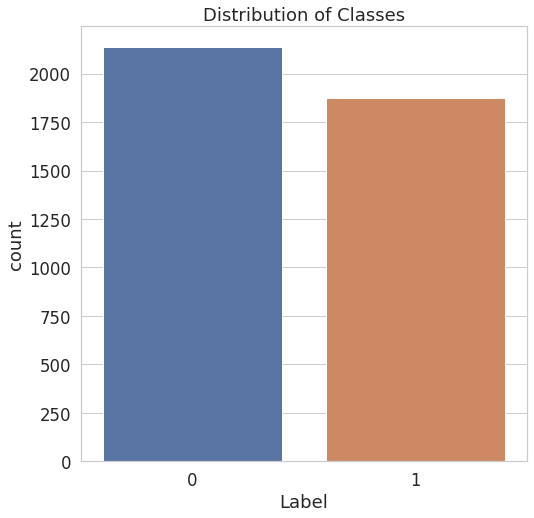

In [ ]:
sns.set(rc={'figure.figsize':(8,8)}, font_scale=1.5, style='whitegrid')
sns.set_style("whitegrid")
sns.countplot(data.Label)
plt.title('Distribution of Classes')

Text(0.5, 1.0, 'Distribution of Labels')

<Figure size 1296x1296 with 0 Axes>

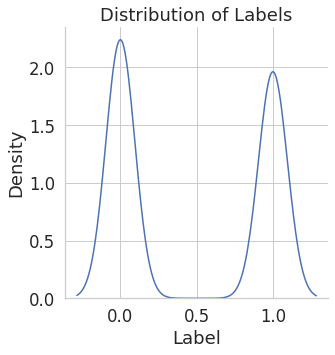

In [ ]:
plt.figure(figsize=(18,18))
sns.displot(data.Label, kind="kde",)
plt.title('Distribution of Labels')

## The distribution of data is normal

## Cleaning text data

In [ ]:
import string
def clean_data(news):
    punc = set(string.punctuation)
    news = ''.join(ch for ch in news if ch not in punc)
    return news

    news = news.lower()
    news = str(text).lower()
    news = re.sub('\[.*?\]', '', news)
    news = re.sub('https?://\S+|www\.\S+', '', news)
    news = re.sub('<.*?>+', '', news)
    news = re.sub('[%s]' % re.escape(string.punctuation), '', news)
    news = re.sub('\n', '', news)
    news = re.sub('\w*\d\w*', '', news)
    news = re.sub('Reuters','',news)
    news = re.sub(r"\d+", "", news)

data['Body'] = data['Body'].apply(lambda x: clean_data(x))
data['Body']

0       Four ways Bob Corker skewered Donald TrumpImag...
1       Linklaters war veteran comedy speaks to modern...
2       Trump’s Fight With Corker Jeopardizes His Legi...
3       Egypts Cheiron wins tieup with Pemex for Mexic...
4       Jason Aldean opens SNL with Vegas tributeCount...
                              ...                        
4004    Trends to WatchTrends to Watch\n of readers th...
4005    Trump Jr Is Soon To Give A 30Minute Speech For...
4006     Ron Paul on Trump Anarchism  the AltRightmissing
4007    China to accept overseas trial data in bid to ...
4008    Vice President Mike Pence Leaves NFL Game Beca...
Name: Body, Length: 4009, dtype: object

In [ ]:
import nltk
nltk.download('stopwords')
# nltk.download('stopwords')
stop = set(stopwords.words('english'))
punctuation = list(string.punctuation)
stop.update(punctuation)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def remove_stopwords(text):
    final_text = []
    for i in text.split():
        if i.strip().lower() not in stop:
            final_text.append(i.strip())
    return " ".join(final_text)

In [ ]:
data['Body']=data['Body'].apply(remove_stopwords)

In [ ]:
# data['Body'] = data['Body'].str.replace('\d+', '')

# World cloud for fake news

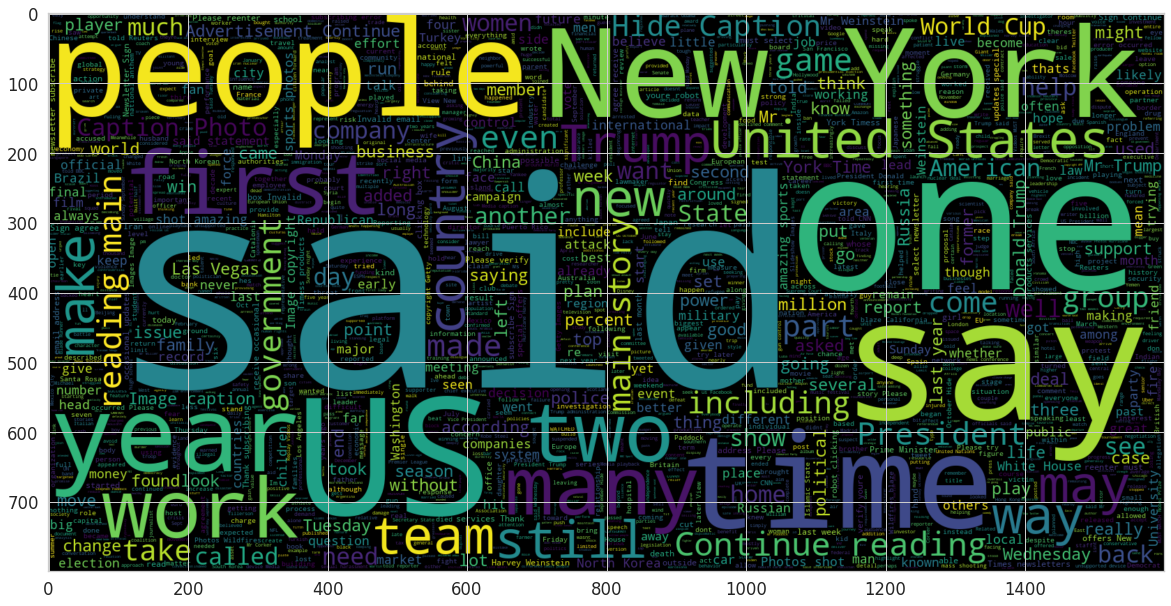

In [ ]:
plt.figure(figsize = (20,20)) # Text that is not Fake
wc = WordCloud(max_words = 2000 , width = 1600 , height = 800 , stopwords = STOPWORDS).generate(" ".join(data[data.Label == 1].Body))
plt.imshow(wc , interpolation = 'bilinear')

### Observation:
- The origins of the news seems to be US as it is the most frequent Geographical location present in the data
- Manipulating narrations
- Fake news are focused on politics specially


# World cloud for true news

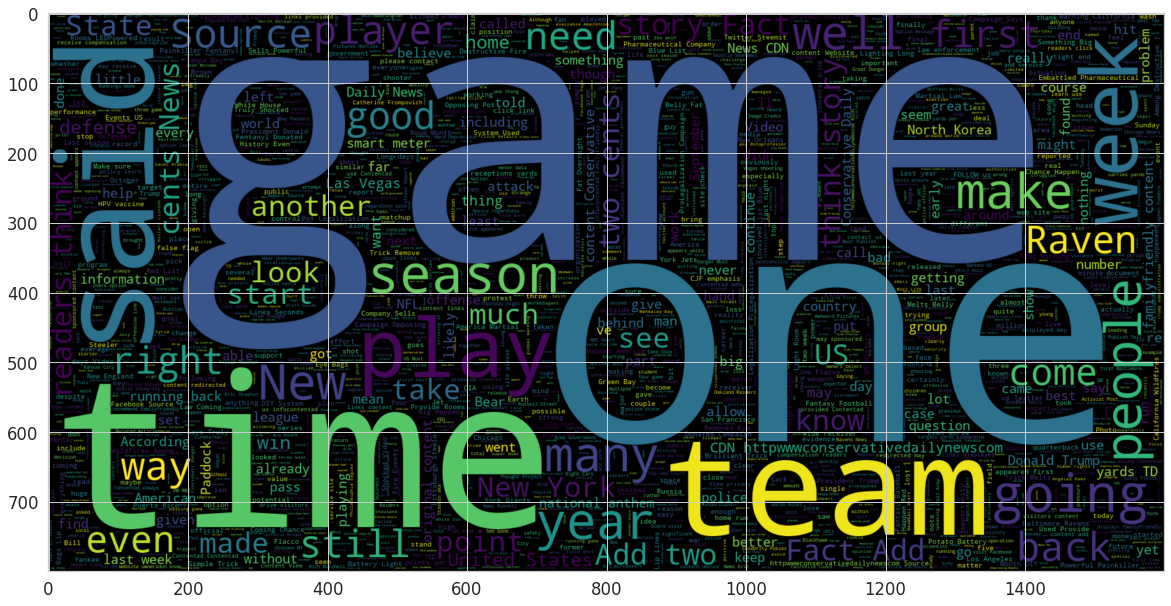

In [ ]:
plt.figure(figsize = (20,20)) # Text that is Fake
wc = WordCloud(max_words = 2000 , width = 1600 , height = 800 , stopwords = STOPWORDS).generate(" ".join(data[data.Label == 0].Body))
plt.imshow(wc , interpolation = 'bilinear')

### Observation:
- True news are focused on games

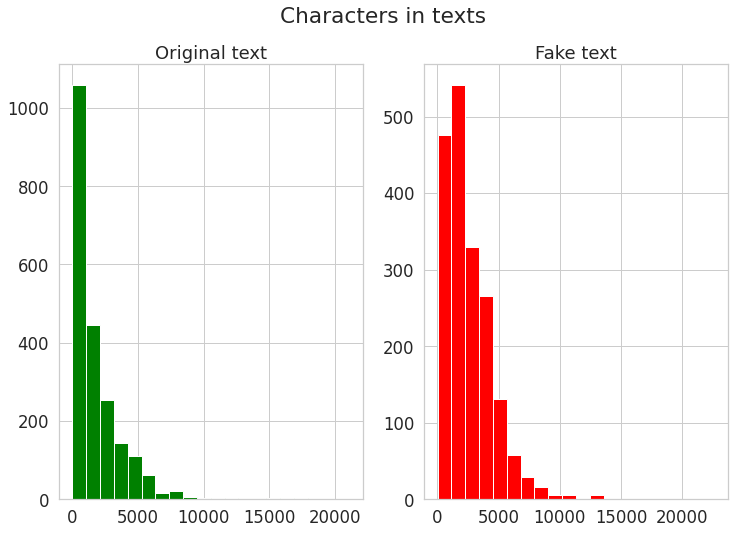

In [ ]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,8))
true_text_len= data[data['Label']==0]['Body'].str.len()
ax1.hist(true_text_len,color='green', bins=20)
ax1.set_title('Original text')

fake_text_len= data[data['Label']==1]['Body'].str.len()
ax2.hist(fake_text_len,color='red', bins=20)
ax2.set_title('Fake text')

fig.suptitle('Characters in texts')
plt.show()

In [ ]:
av_fake = fake_text_len.mean()
print("Average length of fake news: ", round(av_fake, 0))
av_true = true_text_len.mean()
print("Average length of true news: ", round(av_true, 0))

Average length of fake news:  2605.0
Average length of true news:  1733.0


# Observation:
- On average fake news contains 1k more characters then true news

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
def get_top_text_ngrams(corpus, n, g):
    vec = CountVectorizer(ngram_range=(g, g)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

# Unigram Analysis

In [ ]:
# sns.barplot?

Text(0.5, 1.0, 'Unigram Analysis')

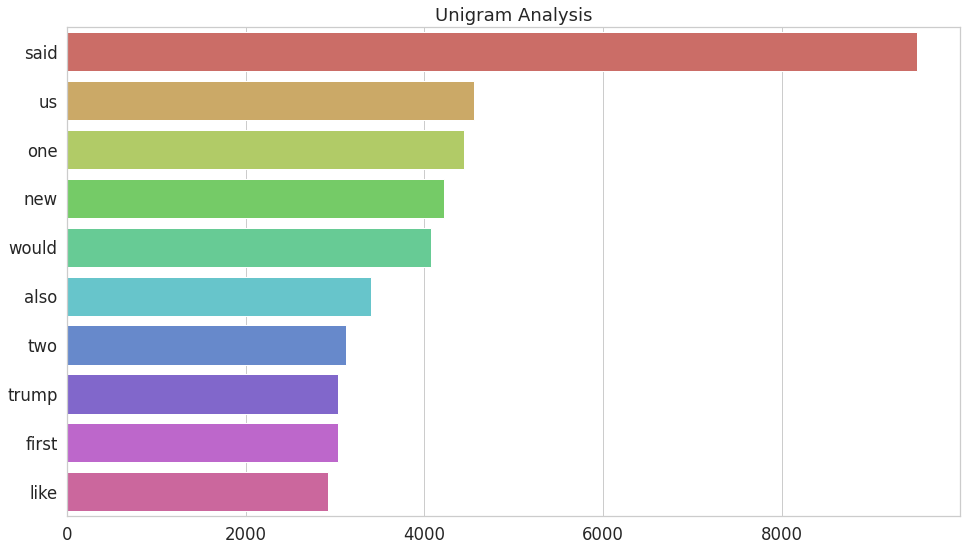

In [ ]:
plt.figure(figsize = (16,9))
most_common_uni = get_top_text_ngrams(data.Body,10,1)
most_common_uni = dict(most_common_uni)
sns.barplot(x=list(most_common_uni.values()),y=list(most_common_uni.keys()), palette='hls')
plt.title("Unigram Analysis")

# Observation:
- Manipulating Narration

# Bigram Analysis

Text(0.5, 1.0, 'Bigram analysis')

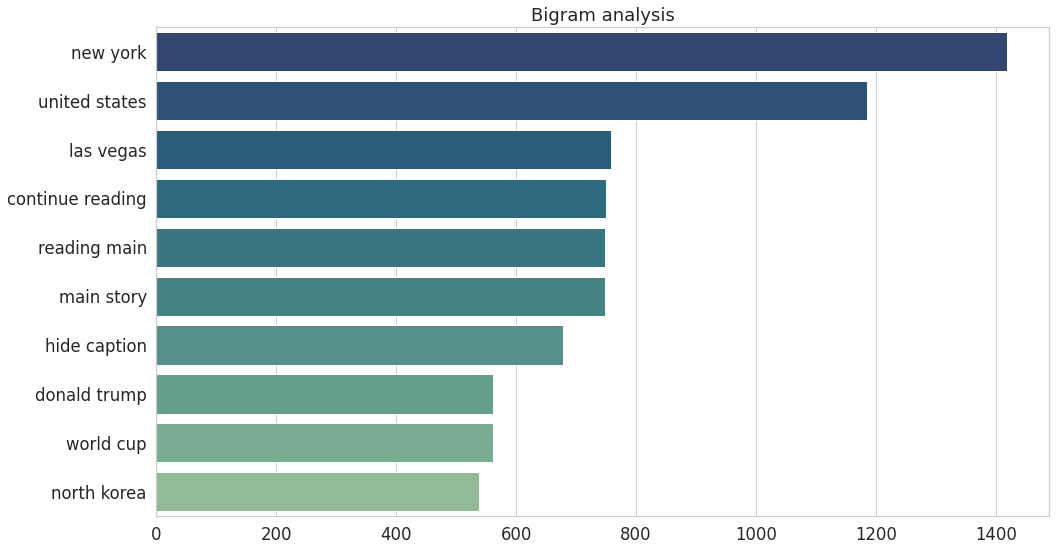

In [ ]:
# palette=plt.get_cmap('crest').reversed()
plt.figure(figsize = (16,9))
most_common_bi = get_top_text_ngrams(data.Body,10,2)
most_common_bi = dict(most_common_bi)
sns.barplot(x=list(most_common_bi.values()),y=list(most_common_bi.keys()), palette='crest_r')
plt.title("Bigram analysis")

# Observation:
- Politics in USA

# Trigram Analysis

Text(0.5, 1.0, 'Trigram Analysis')

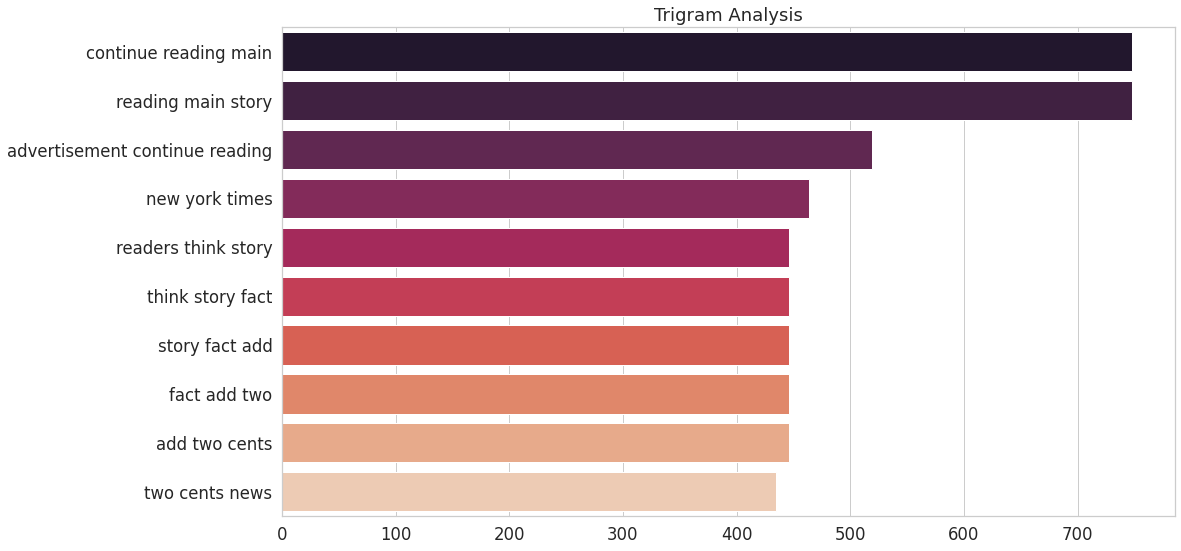

In [ ]:
plt.figure(figsize = (16,9))
most_common_tri = get_top_text_ngrams(data.Body,10,3)
most_common_tri = dict(most_common_tri)
sns.barplot(x=list(most_common_tri.values()),y=list(most_common_tri.keys()), palette="rocket")
plt.title("Trigram Analysis")

# Observation:
- Tends to use informal word

In [ ]:
X = data['Body']
Y = data['Label']

## Splitting data into training and Test set

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.25)

# Tfidf Vectorizer

In [ ]:
vectorization = TfidfVectorizer()
xv_train = vectorization.fit_transform(x_train)
xv_test = vectorization.transform(x_test)

In [ ]:
LR = LogisticRegression()
LR.fit(xv_train,y_train)
LR_pred = LR.predict(xv_test)
score = accuracy_score(y_test,LR_pred)
print('Accuracy of LR model is ', score)
print("Training score: ",accuracy_score(LR.predict(xv_train), y_train))

Accuracy of LR model is  0.9720837487537388
Training score:  0.9943446440452428


In [ ]:
sv =SVC(kernel='linear',random_state=1)
sv.fit(xv_train,y_train)
sv_pred= sv.predict(xv_test)
score = accuracy_score(y_test,sv_pred)
print('Test accuracy of svm model: ', score)
print("Training accuracy of svm model: ",accuracy_score(sv.predict(xv_train), y_train))

Test accuracy of svm model:  0.9850448654037887
Training accuracy of svm model:  0.9993346640053227


Test on a single news article.

In [ ]:
def fake_news_det(news):
    input_data = {"text":[news]}
    new_def_test = pd.DataFrame(input_data)
    new_def_test["text"] = new_def_test["text"].apply(clean_data)
    new_x_test = new_def_test["text"]
    #print(new_x_test)
    vectorized_input_data = vectorization.transform(new_x_test)
    prediction = sv.predict(vectorized_input_data)

    if prediction == 1:
        print("Not a Fake News")
    else:
        print("Fake News")